# Exploratory Data Analysis (EDA)
### **Notebook Overview**
This notebook performs an **Exploratory Data Analysis (EDA)** on the Campus Recruitment dataset. 
EDA helps us:
1. Understand the dataset
2. Identify patterns
3. Prepare for machine learning modeling.

**Import the important libraries**

1. Pandas for: data analysis, cleaning and manipulation
2. Matplotlib.pyplot for: data visualization and interactive plots (dynamic exploration of data)
3. Seaborn for: integration with pandas (visualize data directly from DataFrames without needing to convert them to other formats) and statistical plots ( provides specialized functions for creating statistical plots)

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Training DataSet**

In [16]:
file_path = r'DataSet\train_campusrecruit.csv'
df = pd.read_csv(file_path)

**Drop rows with missing values**

In [ ]:
# df.dropna(inplace=True)

**Display first few rows**

In [19]:
df.head()

,id,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,61,M,61.84,Others,57.93,Others,Science,68.03,Sci&Tech,No,60.60,Mkt&HR,55.10,Not Placed,0.0
1,273,M,63.06,Central,75.61,Central,Commerce,63.40,Comm&Mgmt,Yes,62.33,Mkt&HR,54.69,Placed,424507.0
2,489,M,76.34,Central,63.37,Central,Science,71.33,Sci&Tech,No,53.98,Mkt&HR,53.03,Placed,200000.0
3,721,M,54.12,Others,65.47,Others,Commerce,73.83,Comm&Mgmt,Yes,62.09,Mkt&Fin,58.87,Not Placed,0.0
4,95,M,63.12,Others,68.94,Central,Commerce,66.08,Comm&Mgmt,Yes,71.99,Mkt&HR,67.01,Placed,327148.0


**Understading the Data**

In [21]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 699
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              700 non-null    int64  
 1   gender          700 non-null    object 
 2   ssc_p           700 non-null    float64
 3   ssc_b           700 non-null    object 
 4   hsc_p           700 non-null    float64
 5   hsc_b           700 non-null    object 
 6   hsc_s           700 non-null    object 
 7   degree_p        700 non-null    float64
 8   degree_t        700 non-null    object 
 9   workex          700 non-null    object 
 10  etest_p         700 non-null    float64
 11  specialisation  700 non-null    object 
 12  mba_p           700 non-null    float64
 13  status          700 non-null    object 
 14  salary          700 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 87.5+ KB


,id,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,509.958571,66.610957,65.880457,66.370743,72.048686,62.434157,193409.420000
std,283.885729,11.216839,10.968154,7.644842,13.739664,6.229540,158175.546966
min,2.000000,40.890000,37.000000,50.000000,50.000000,51.210000,0.000000
25%,268.750000,58.927500,59.432500,61.587500,60.022500,57.660000,0.000000
50%,506.500000,66.465000,65.460000,66.420000,70.940000,62.120000,206248.000000
75%,758.250000,75.077500,72.622500,71.392500,82.855000,66.927500,294150.750000
max,999.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


**Check for missing values**

In [44]:
df.isnull().sum()

id                0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

**Explore Target Variable**

Placed / Not Placed

C:\Users\30698\AppData\Local\Temp\ipykernel_13220\596845698.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="status", palette=["#ff9999", "#66b3ff"])


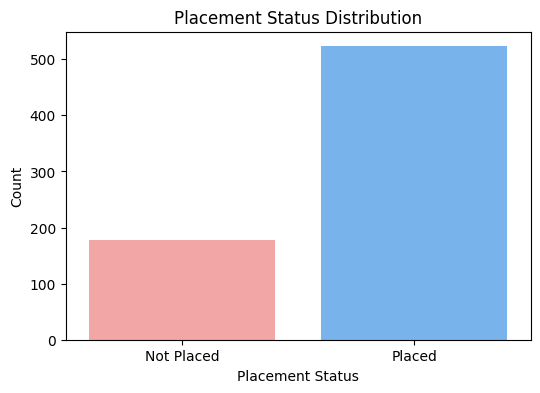

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="status", palette=["#ff9999", "#66b3ff"])
plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.show()

**Analyzing Numerical Features**

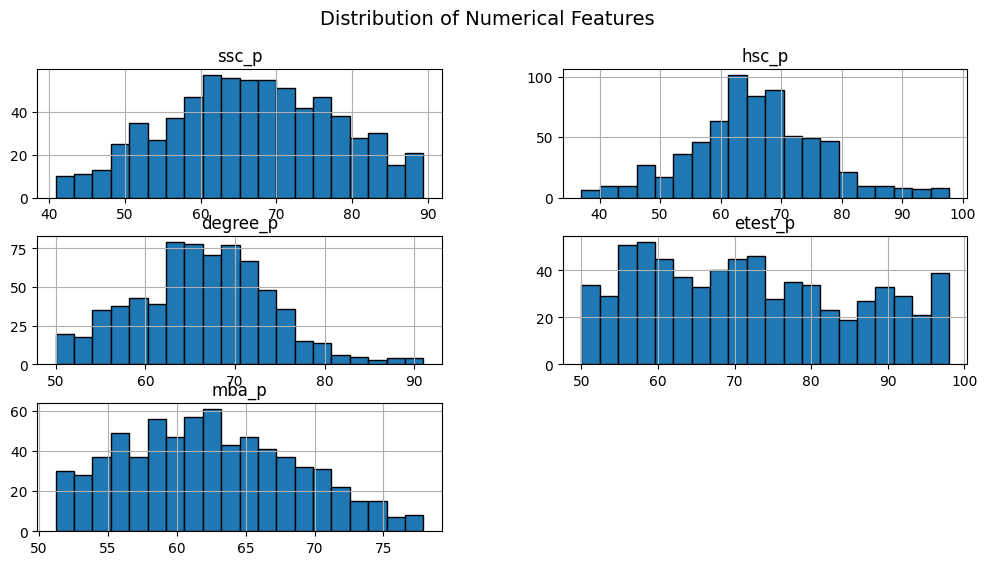

In [26]:
numerical_features = ["ssc_p", "hsc_p", "degree_p", "etest_p", "mba_p"]
df[numerical_features].hist(figsize=(12, 6), bins=20, edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

**Analyzing Categorical Features**

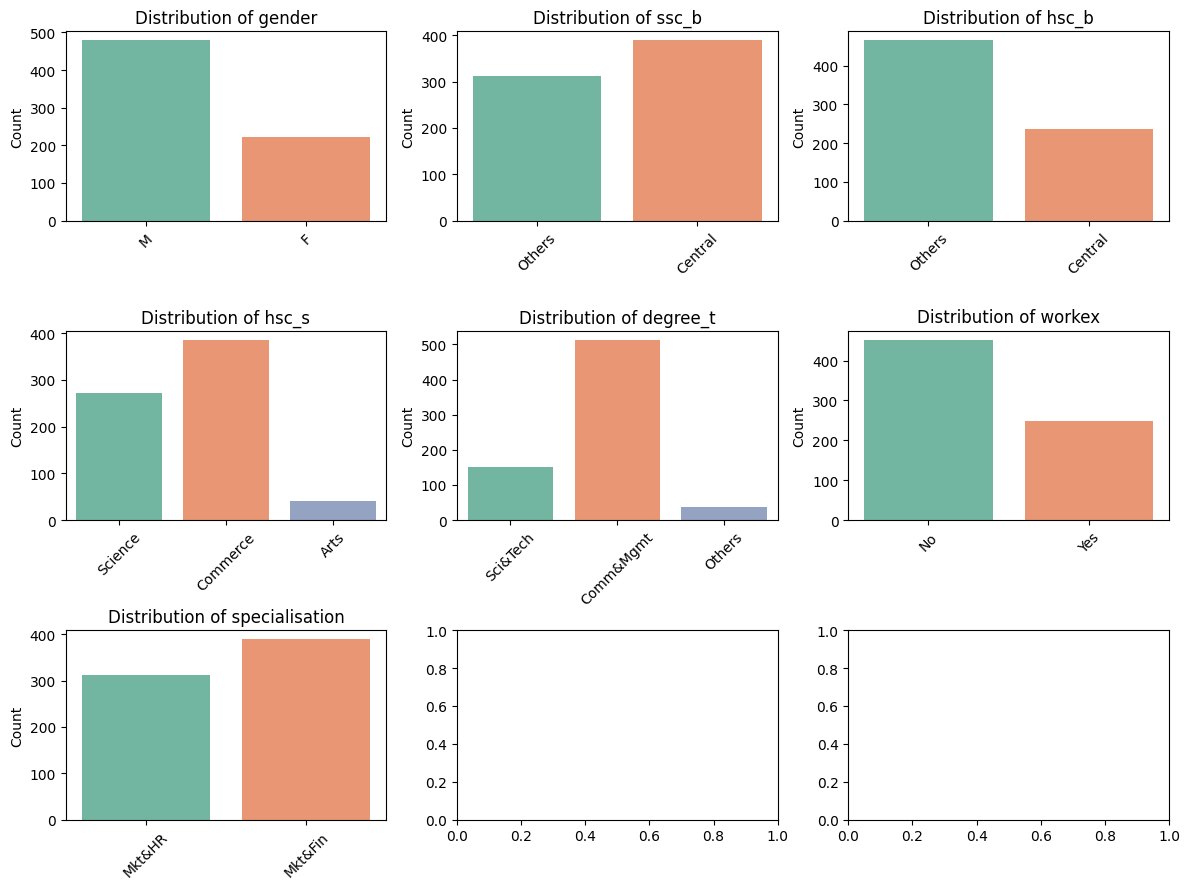

In [27]:
categorical_features = ["gender", "ssc_b", "hsc_b", "hsc_s", "degree_t", "workex", "specialisation"]	

# Visualizing categorical features
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, hue=col, ax=axes[i], palette="Set2", legend=False)

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Feature Correlations**

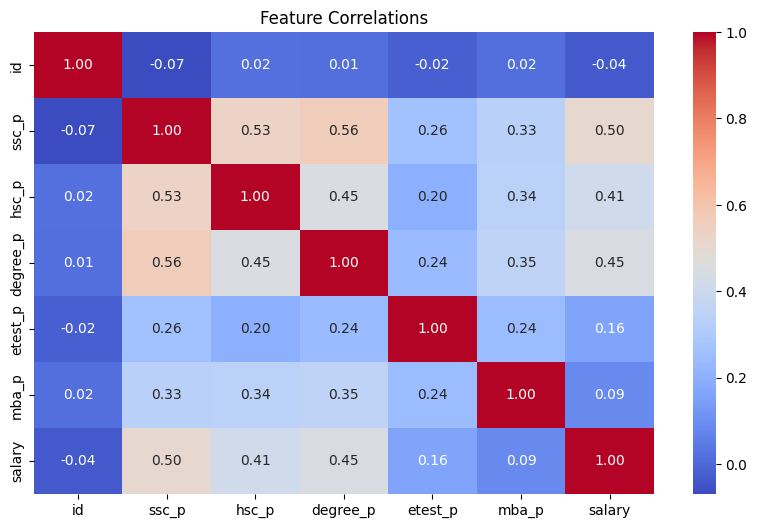

In [28]:
plt.figure(figsize=(10,6))
numeric_cols = df.select_dtypes(include=['number'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlations")
plt.show()

**Summary**

1. The train DataSet is imbalanced: More students placed than not placed
2. Strong correlation exists among academic performance metrics.
3. Categorical variables show clear trends (e.g., work experience is rare).